In [55]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [56]:
img = plt.imread("1.jpg")
if img.ndim == 3:  
    img = np.mean(img, axis=2)

In [57]:
img = cv2.resize(img, (64, 64), interpolation=cv2.INTER_LINEAR)

(-0.5, 63.5, 63.5, -0.5)

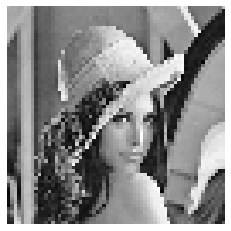

In [58]:
plt.imshow(img, cmap="gray")
plt.axis("off")

In [59]:
def dft2d(image):
    M, N = image.shape
    F = np.zeros((M, N), dtype=complex)
    for u in range(M):
        for v in range(N):
            sum_val = 0
            for x in range(M):
                for y in range(N):
                    angle = -2j * np.pi * ((u*x/M) + (v*y/N))
                    sum_val += image[x, y] * np.exp(angle)
            F[u, v] = sum_val 
    return F

In [60]:
def idft2d(F):
    M, N = F.shape
    image = np.zeros((M, N), dtype=complex)
    for x in range(M):
        for y in range(N):
            sum_val = 0
            for u in range(M):
                for v in range(N):
                    angle = 2j * np.pi * ((u*x/M) + (v*y/N))
                    sum_val += F[u, v] * np.exp(angle)
            image[x, y] = sum_val / (M*N)
    return np.real(image)

In [61]:
def fft_shift(F):
    M, N = F.shape
    shifted = np.zeros_like(F, dtype=complex)
    for u in range(M):
        for v in range(N):
            shifted[u, v] = F[(u + M//2) % M, (v + N//2) % N]
    return shifted

def ifft_shift(F):
    return fft_shift(F)

In [62]:
def high_pass_filter(F, radius=2):
    M, N = F.shape
    center_x, center_y = M // 2, N // 2
    for i in range(M):
        for j in range(N):
            if (i - center_x)**2 + (j - center_y)**2 <= radius**2:
                F[i, j] = 0
    return F

In [63]:
F = dft2d(img)
F_shifted = fft_shift(F)
F_filtered = high_pass_filter(F_shifted.copy(), radius=10)
F_inverse_shift = ifft_shift(F_filtered)
img_filtered = idft2d(F_inverse_shift)

(-0.5, 511.5, 511.5, -0.5)

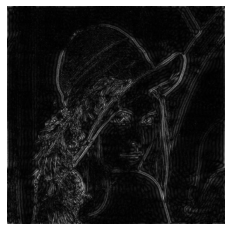

In [6]:
plt.imshow(filtered_img, cmap='gray')
plt.axis('off')

In [44]:
def low_pass_filter(F, radius=10):
    M, N = F.shape
    cx, cy = M // 2, N // 2
    filtered = np.zeros_like(F, dtype=complex)
    for i in range(M):
        for j in range(N):
            if (i - cx)**2 + (j - cy)**2 <= radius**2:
                filtered[i, j] = F[i, j] 
            else:
                filtered[i, j] = 0      
    
    return filtered

In [53]:
F_filtered = low_pass_filter(F_shifted.copy(), radius=5)
F_inv_shift = ifft_shift(F_filtered)
img_filtered = idft2d(F_inv_shift)

(-0.5, 63.5, 63.5, -0.5)

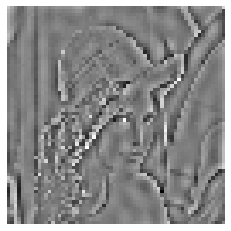

In [64]:
plt.imshow(img_filtered, cmap="gray")
plt.axis("off")